In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)

# Load all data
portfolio  = pd.read_csv("data/portfolio.csv",           index_col="label")
krd        = pd.read_csv("data/krd.csv",                 index_col="bond")
pnl_df     = pd.read_csv("data/scenario_pnl.csv",        index_col="scenario")
moves      = pd.read_csv("data/scenario_moves.csv",       index_col="scenario")
hedged_df  = pd.read_csv("data/hedged_pnl.csv",          index_col="scenario")
eff_df     = pd.read_csv("data/hedge_effectiveness.csv", index_col="scenario")
base_curve = pd.read_csv("data/base_curve.csv",          index_col=0).iloc[:, 0]
scenarios  = pd.read_csv("data/scenarios.csv",           index_col="scenario")

# Portfolio aggregates
port_price = portfolio["price"].sum()
port_dv01  = portfolio["dv01"].sum()
port_dur   = (portfolio["mod_dur"] * portfolio["price"]).sum() / port_price
port_conv  = (portfolio["convexity"] * portfolio["price"]).sum() / port_price
port_krd   = (krd.T * portfolio["price"]).sum(axis=1) / port_price

# Scenario lists
all_sc    = [s for s in hedged_df.index if not s.startswith("mc_")]
non_mc_sc = all_sc

TENORS = list(base_curve.index)
TAUS   = [1/12,3/12,6/12,1,2,3,5,7,10,20,30]

print("All data loaded successfully.")
print(f"Portfolio : {len(portfolio)} bonds  |  ${port_price/1e6:.2f}M")
print(f"Scenarios : {len(all_sc)} stress scenarios")

All data loaded successfully.
Portfolio : 12 bonds  |  $51.55M
Scenarios : 21 stress scenarios



SECTION 1 — PORTFOLIO CONSTITUENTS
          Coupon    Face ($)  Maturity (yr)   Price ($) Price (%)
label                                                            
2yr_2pct   2.00%  $2,000,000              2  $1,933,754    96.69%
2yr_4pct   4.00%  $3,000,000              2  $3,015,256   100.51%
5yr_3pct   3.00%  $5,000,000              5  $4,768,185    95.36%
5yr_5pct   5.00%  $4,000,000              5  $4,174,928   104.37%
7yr_3pct   3.00%  $3,000,000              7  $2,780,622    92.69%
7yr_4pct   4.00%  $5,000,000              7  $4,936,866    98.74%
10yr_3pct  3.00%  $8,000,000             10  $7,094,115    88.68%
10yr_5pct  5.00%  $6,000,000             10  $6,293,203   104.89%
20yr_4pct  4.00%  $4,000,000             20  $3,656,121    91.40%
20yr_5pct  5.00%  $3,000,000             20  $3,135,263   104.51%
30yr_3pct  3.00%  $5,000,000             30  $3,598,175    71.96%
30yr_4pct  4.00%  $7,000,000             30  $6,166,591    88.09%

SUMMARY:
  Total face value   : $55.00M

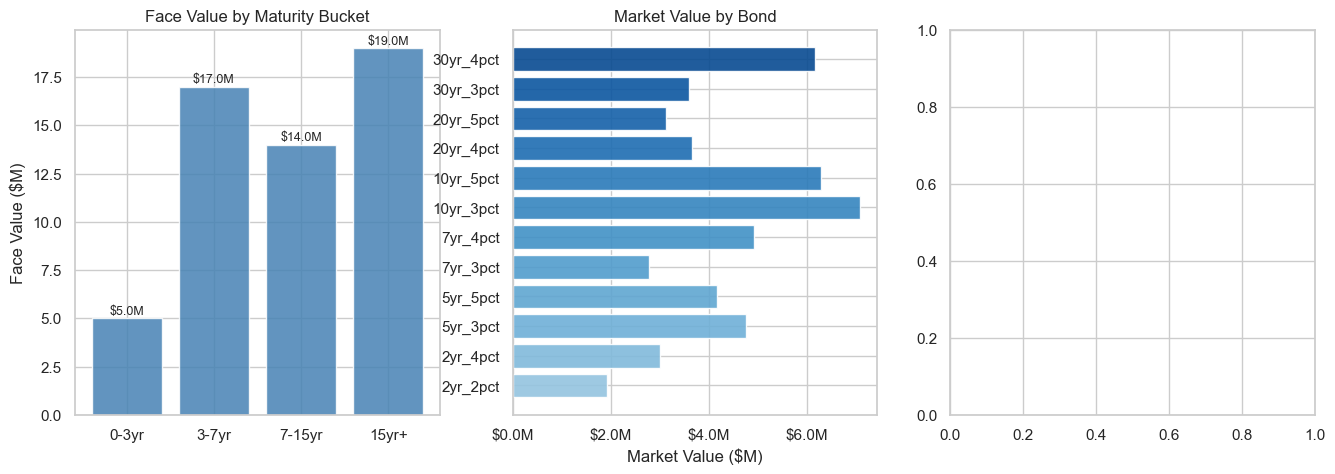

In [2]:
print("\n" + "="*65)
print("SECTION 1 — PORTFOLIO CONSTITUENTS")
print("="*65)

display_cols = portfolio[["coupon","face","maturity","price","price_pct"]].copy()
display_cols.columns = ["Coupon","Face ($)","Maturity (yr)","Price ($)","Price (%)"]
display_cols["Coupon"] = (display_cols["Coupon"] * 100).map("{:.2f}%".format)
display_cols["Face ($)"]  = display_cols["Face ($)"].map("${:,.0f}".format)
display_cols["Price ($)"] = display_cols["Price ($)"].map("${:,.0f}".format)
display_cols["Price (%)"] = display_cols["Price (%)"].map("{:.2f}%".format)
print(display_cols.to_string())

print(f"\nSUMMARY:")
print(f"  Total face value   : ${portfolio['face'].sum()/1e6:.2f}M")
print(f"  Total market value : ${port_price/1e6:.2f}M")
print(f"  Number of bonds    : {len(portfolio)}")
print(f"  Maturity range     : {portfolio['maturity'].min()}yr — "
      f"{portfolio['maturity'].max()}yr")
print(f"  Coupon range       : "
      f"{portfolio['coupon'].min()*100:.0f}% — "
      f"{portfolio['coupon'].max()*100:.0f}%")

# Portfolio composition chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Face value by maturity bucket
buckets = {"0-3yr": ["2yr_2pct","2yr_4pct"],
           "3-7yr": ["5yr_3pct","5yr_5pct","7yr_3pct","7yr_4pct"],
           "7-15yr":["10yr_3pct","10yr_5pct"],
           "15yr+": ["20yr_4pct","20yr_5pct","30yr_3pct","30yr_4pct"]}
bucket_face = {b: portfolio.loc[labels,"face"].sum()/1e6
               for b, labels in buckets.items()}
axes[0].bar(bucket_face.keys(), bucket_face.values(),
            color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Face Value ($M)")
axes[0].set_title("Face Value by Maturity Bucket")
for i, (k, v) in enumerate(bucket_face.items()):
    axes[0].text(i, v + 0.2, f"${v:.1f}M", ha="center", fontsize=9)

# Chart 2: Market value by bond (horizontal bar)
portfolio_sorted = portfolio.sort_values("maturity")
colors_bar = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(portfolio_sorted)))
axes[1].barh(portfolio_sorted.index,
             portfolio_sorted["price"]/1e6,
             color=colors_bar, edgecolor="white", alpha=0.9)
axes[1].set_xlabel("Market Value ($M)")
axes[1].set_title("Market Value by Bond")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))


SECTION 2 — RISK PROFILE

  Market Value        : $51.55M
  Modified Duration   : 8.84 years
  DV01 (total)        : $45,581
  Convexity           : 135.20

  Interpretation:
  → For every 1bp rates rise, portfolio loses $45,581
  → For a 100bp parallel move, estimated loss = $4,558K
  → For a 300bp parallel move, estimated loss = $13,674K


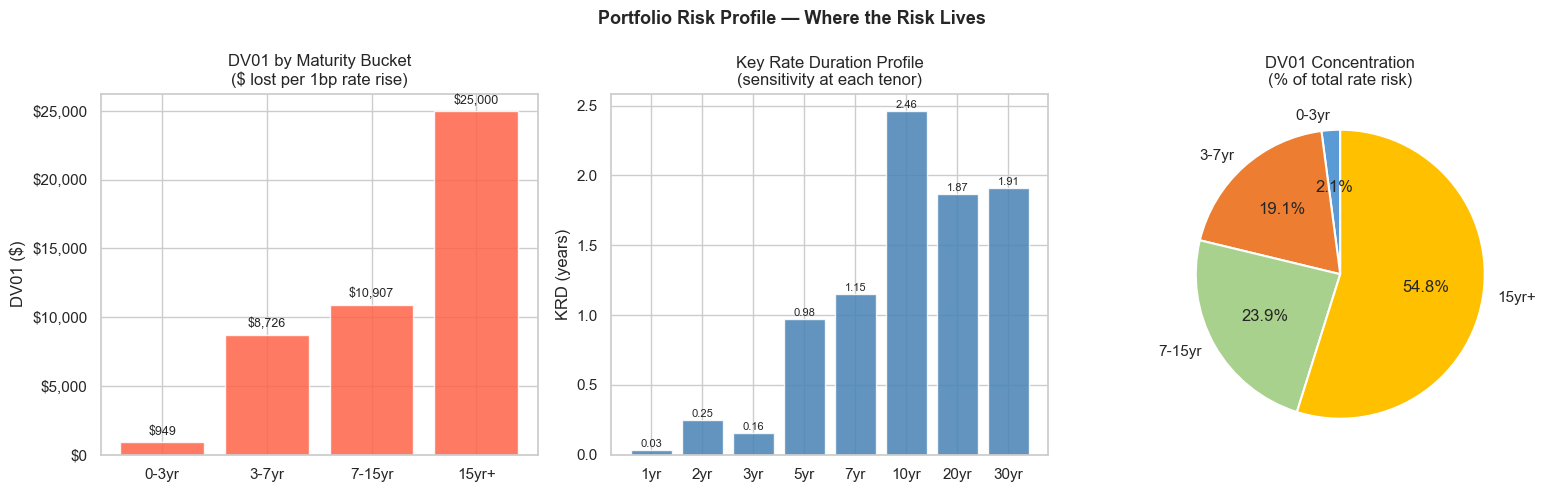

In [3]:
print("\n" + "="*65)
print("SECTION 2 — RISK PROFILE")
print("="*65)
print(f"\n  Market Value        : ${port_price/1e6:.2f}M")
print(f"  Modified Duration   : {port_dur:.2f} years")
print(f"  DV01 (total)        : ${port_dv01:,.0f}")
print(f"  Convexity           : {port_conv:.2f}")
print(f"\n  Interpretation:")
print(f"  → For every 1bp rates rise, portfolio loses ${port_dv01:,.0f}")
print(f"  → For a 100bp parallel move, estimated loss = "
      f"${port_dv01*100/1e3:,.0f}K")
print(f"  → For a 300bp parallel move, estimated loss = "
      f"${port_dv01*300/1e3:,.0f}K")

# DV01 by bucket
bucket_dv01 = {b: portfolio.loc[labels,"dv01"].sum()
               for b, labels in buckets.items()}

# KRD profile
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: DV01 by bucket
bars = axes[0].bar(bucket_dv01.keys(), bucket_dv01.values(),
                   color="tomato", alpha=0.85, edgecolor="white")
axes[0].bar_label(bars, fmt="${:,.0f}", padding=3, fontsize=9)
axes[0].set_ylabel("DV01 ($)")
axes[0].set_title("DV01 by Maturity Bucket\n($ lost per 1bp rate rise)")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Chart 2: KRD profile
krd_plot = port_krd[["1yr","2yr","3yr","5yr","7yr","10yr","20yr","30yr"]]
axes[1].bar(krd_plot.index, krd_plot.values,
            color="steelblue", alpha=0.85, edgecolor="white")
axes[1].set_ylabel("KRD (years)")
axes[1].set_title("Key Rate Duration Profile\n"
                  "(sensitivity at each tenor)")
for i, (t, v) in enumerate(krd_plot.items()):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

# Chart 3: DV01 concentration pie
axes[2].pie(list(bucket_dv01.values()),
            labels=list(bucket_dv01.keys()),
            autopct="%1.1f%%",
            colors=["#5b9bd5","#ed7d31","#a9d18e","#ffc000"],
            startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[2].set_title("DV01 Concentration\n(% of total rate risk)")

plt.suptitle("Portfolio Risk Profile — Where the Risk Lives",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/pres_02_risk_profile.png", dpi=150)
plt.show()



SECTION 3 — STRESS TEST SCENARIOS

  Scenarios run      : 21
  Worst scenario     : parallel_up_300
  Worst P&L          : $-11,092.9K  (-21.52% of portfolio)
  Best scenario      : parallel_down_200
  Best P&L           : $10,734.1K  (20.82% of portfolio)

  Scenarios with loss > $5M  : 11
  Scenarios with loss > $10M : 10

  SCENARIO P&L DETAIL:
  ---------------------------------------------
  parallel_up_300           −$11092.9K  [LOSS]
  rate_shock_2022           −$ 9053.2K  [LOSS]
  parallel_up_200           −$ 7896.1K  [LOSS]
  stagflation               −$ 7085.7K  [LOSS]
  bear_steepener            −$ 5584.8K  [LOSS]
  taper_tantrum_2013        −$ 4802.6K  [LOSS]
  parallel_up_100           −$ 4232.6K  [LOSS]
  bear_flattener            −$ 2191.9K  [LOSS]
  hump                      −$ 1233.9K  [LOSS]
  inversion                 −$  224.0K  [LOSS]
  fed_cut_50bps             −$    8.9K  [LOSS]
  fed_cut_25bps             −$    4.5K  [LOSS]
  fed_hike_25bps            +$    4.6

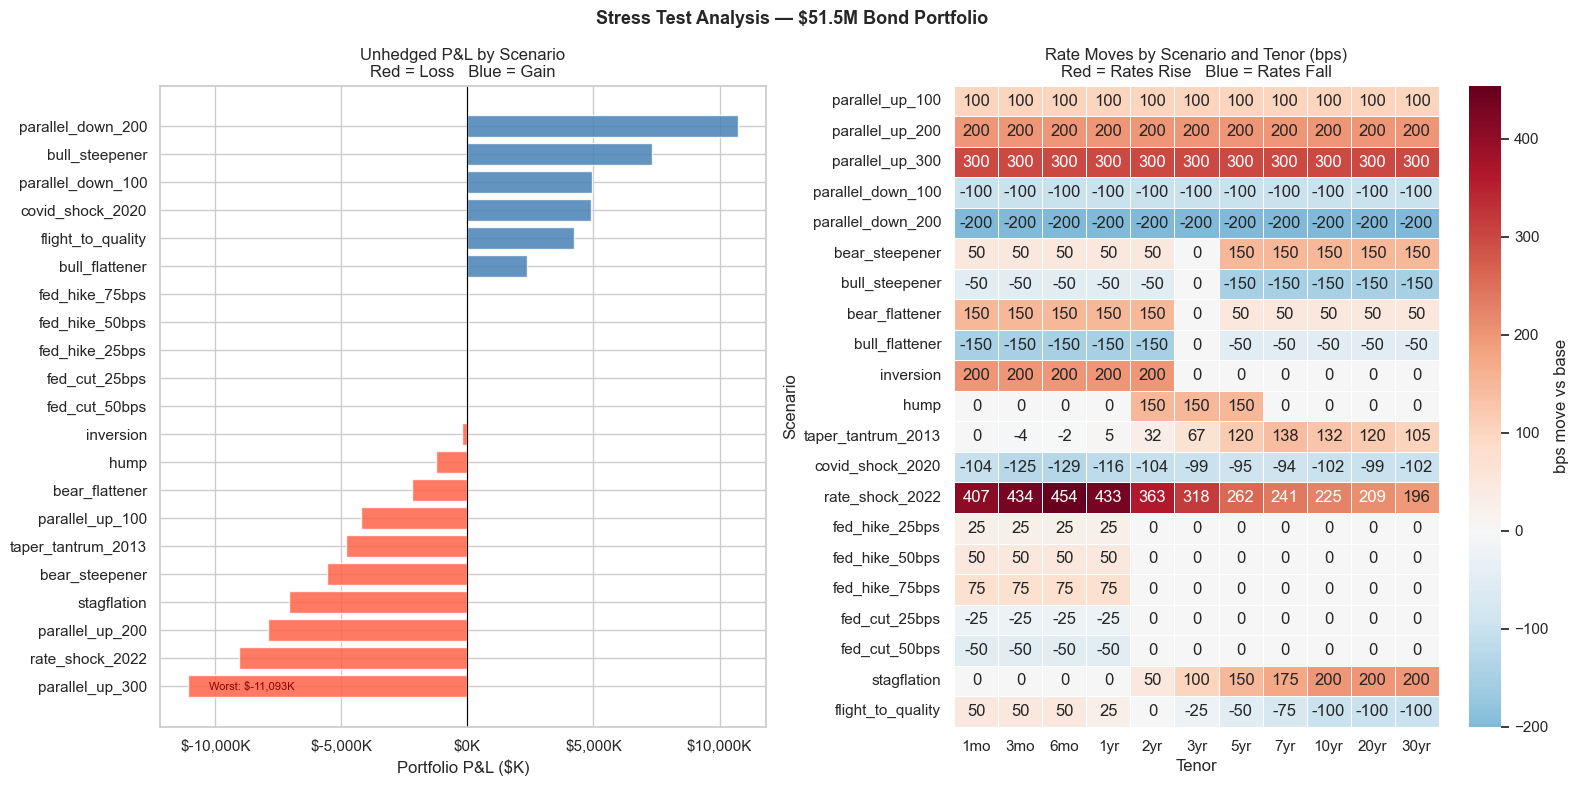

In [4]:
#── CELL 4: SECTION 3 — Stress Test ──────────────────────────
print("\n" + "="*65)
print("SECTION 3 — STRESS TEST SCENARIOS")
print("="*65)

pnl_total  = pnl_df.loc[all_sc, "total"].sort_values()
worst_sc   = pnl_total.idxmin()
best_sc    = pnl_total.idxmax()

print(f"\n  Scenarios run      : {len(all_sc)}")
print(f"  Worst scenario     : {worst_sc}")
print(f"  Worst P&L          : ${pnl_total.min()/1e3:,.1f}K  "
      f"({pnl_total.min()/port_price*100:.2f}% of portfolio)")
print(f"  Best scenario      : {best_sc}")
print(f"  Best P&L           : ${pnl_total.max()/1e3:,.1f}K  "
      f"({pnl_total.max()/port_price*100:.2f}% of portfolio)")
print(f"\n  Scenarios with loss > $5M  : "
      f"{(pnl_total < -5000).sum()}")
print(f"  Scenarios with loss > $10M : "
      f"{(pnl_total < -10000).sum()}")

print(f"\n  SCENARIO P&L DETAIL:")
print(f"  {'-'*45}")
for sc, val in pnl_total.items():
    tag = "LOSS" if val < 0 else "GAIN"
    print(f"  {sc:<25} "
          f"{'−' if val<0 else '+'}${abs(val)/1e3:>7.1f}K  [{tag}]")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Chart 1: P&L bar chart
colors_pnl = ["tomato" if v < 0 else "steelblue"
               for v in pnl_total.values]
axes[0].barh(pnl_total.index, pnl_total.values/1e3,
             color=colors_pnl, edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Portfolio P&L ($K)")
axes[0].set_title("Unhedged P&L by Scenario\n"
                  "Red = Loss   Blue = Gain")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
axes[0].annotate(f"Worst: ${pnl_total.min()/1e3:,.0f}K",
                 xy=(pnl_total.min()/1e3, worst_sc),
                 xytext=(15, 0), textcoords="offset points",
                 fontsize=8, color="darkred", va="center")

# Chart 2: Rate moves heatmap
non_mc_moves = moves.loc[all_sc].astype(float)
sns.heatmap(non_mc_moves, annot=True, fmt=".0f",
            cmap="RdBu_r", center=0, ax=axes[1],
            linewidths=0.4,
            cbar_kws={"label":"bps move vs base"})
axes[1].set_title("Rate Moves by Scenario and Tenor (bps)\n"
                  "Red = Rates Rise   Blue = Rates Fall")
axes[1].set_xlabel("Tenor")
axes[1].set_ylabel("Scenario")

plt.suptitle("Stress Test Analysis — $51.5M Bond Portfolio",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/pres_03_stress_test.png", dpi=150)
plt.show()



SECTION 4 — HEDGING STRATEGIES

Three strategies compared:

  S1 — Duration Neutral
       Short 10yr Treasury futures (TY) to zero out total DV01
       Simple, cheap, works well for parallel rate moves
       Weakness: blind to curve shape changes

  S2 — KRD Hedge
       Spread contracts across TU/FV/TY/US to match
       key rate duration at each tenor bucket
       Strength: protects against steepeners, flatteners,
                 inversions, humps
       Weakness: slightly weaker on pure parallel moves

  S4 — Combined Hedge (recommended)
       KRD contract mix scaled to full DV01 coverage
       Best of both worlds — strong on parallel AND
       curve shape scenarios



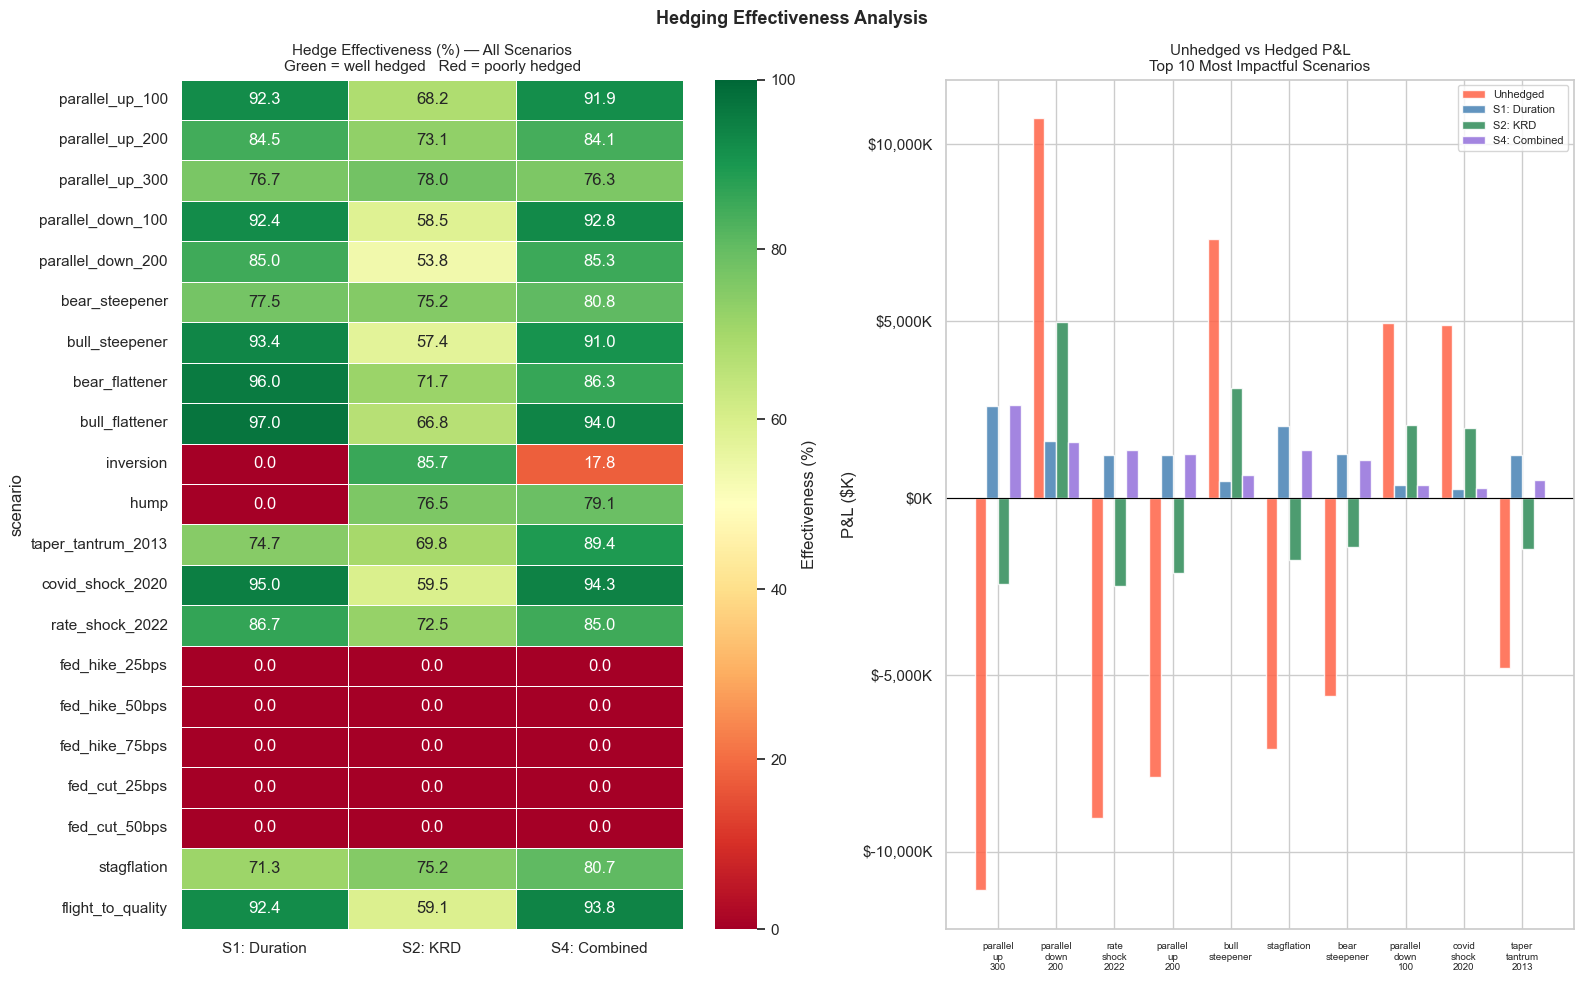


EFFECTIVENESS SUMMARY TABLE
Scenario                    Unhedged    S1($K)    S1%    S2($K)    S2%    S4($K)    S4%
------------------------------------------------------------------------------------------
parallel_up_100             -4,232.6     327.4  92.3%  -1,347.1  68.2%     342.9  91.9%
parallel_up_200             -7,896.1   1,223.9  84.5%  -2,125.1  73.1%   1,254.9  84.1%
parallel_up_300            -11,092.9   2,587.1  76.7%  -2,436.4  78.0%   2,633.6  76.3%
parallel_down_100            4,932.7     372.7  92.4%   2,047.2  58.5%     357.2  92.8%
parallel_down_200           10,734.1   1,614.1  85.0%   4,963.1  53.8%   1,583.1  85.3%
bear_steepener              -5,584.8   1,255.2  77.5%  -1,384.6  75.2%   1,074.4  80.8%
bull_steepener               7,320.2     480.2  93.4%   3,120.0  57.4%     661.0  91.0%
bear_flattener              -2,191.9      88.1  96.0%    -621.2  71.7%     299.8  86.3%
bull_flattener               2,351.7      71.7  97.0%     780.9  66.8%    -140.1  94.0%


In [5]:
#── CELL 5: SECTION 4 — Hedging ──────────────────────────────
print("\n" + "="*65)
print("SECTION 4 — HEDGING STRATEGIES")
print("="*65)
print("""
Three strategies compared:

  S1 — Duration Neutral
       Short 10yr Treasury futures (TY) to zero out total DV01
       Simple, cheap, works well for parallel rate moves
       Weakness: blind to curve shape changes

  S2 — KRD Hedge
       Spread contracts across TU/FV/TY/US to match
       key rate duration at each tenor bucket
       Strength: protects against steepeners, flatteners,
                 inversions, humps
       Weakness: slightly weaker on pure parallel moves

  S4 — Combined Hedge (recommended)
       KRD contract mix scaled to full DV01 coverage
       Best of both worlds — strong on parallel AND
       curve shape scenarios
""")

# Effectiveness heatmap
eff_matrix = eff_df.loc[all_sc,
             ["s1_eff_%","s2_eff_%","s4_eff_%"]].copy()
eff_matrix.columns = ["S1: Duration","S2: KRD","S4: Combined"]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.heatmap(eff_matrix.astype(float),
            annot=True, fmt=".1f",
            cmap="RdYlGn", center=50,
            vmin=0, vmax=100,
            ax=axes[0], linewidths=0.5,
            cbar_kws={"label":"Effectiveness (%)"})
axes[0].set_title("Hedge Effectiveness (%) — All Scenarios\n"
                  "Green = well hedged   Red = poorly hedged",
                  fontsize=11)

# Per-scenario grouped bar — top 10 most impactful scenarios
top_sc = pnl_df.loc[all_sc,"total"].abs().nlargest(10).index.tolist()
x      = np.arange(len(top_sc))
width  = 0.20

axes[1].bar(x-width*1.5, hedged_df.loc[top_sc,"unhedged"]/1e3,
            width, label="Unhedged",     color="tomato",
            alpha=0.85, edgecolor="white")
axes[1].bar(x-width*0.5, hedged_df.loc[top_sc,"s1_hedged"]/1e3,
            width, label="S1: Duration", color="steelblue",
            alpha=0.85, edgecolor="white")
axes[1].bar(x+width*0.5, hedged_df.loc[top_sc,"s2_hedged"]/1e3,
            width, label="S2: KRD",      color="seagreen",
            alpha=0.85, edgecolor="white")
axes[1].bar(x+width*1.5, hedged_df.loc[top_sc,"s4_hedged"]/1e3,
            width, label="S4: Combined", color="mediumpurple",
            alpha=0.85, edgecolor="white")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([s.replace("_","\n") for s in top_sc],
                         fontsize=7)
axes[1].set_ylabel("P&L ($K)")
axes[1].set_title("Unhedged vs Hedged P&L\nTop 10 Most Impactful Scenarios",
                  fontsize=11)
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

plt.suptitle("Hedging Effectiveness Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/pres_04_hedging.png", dpi=150)
plt.show()

# Effectiveness summary table
print("\nEFFECTIVENESS SUMMARY TABLE")
print("="*90)
print(f"{'Scenario':<25} {'Unhedged':>10} "
      f"{'S1($K)':>9} {'S1%':>6} "
      f"{'S2($K)':>9} {'S2%':>6} "
      f"{'S4($K)':>9} {'S4%':>6}")
print("-"*90)
for sc in all_sc:
    r = hedged_df.loc[sc]
    e = eff_df.loc[sc]
    print(f"{sc:<25} "
          f"{r['unhedged']/1e3:>10,.1f} "
          f"{r['s1_hedged']/1e3:>9,.1f} {e['s1_eff_%']:>5.1f}% "
          f"{r['s2_hedged']/1e3:>9,.1f} {e['s2_eff_%']:>5.1f}% "
          f"{r['s4_hedged']/1e3:>9,.1f} {e['s4_eff_%']:>5.1f}%")
print("-"*90)
print(f"{'Average':<25} {'':>10} "
      f"{'':>9} {eff_df['s1_eff_%'].mean():>5.1f}% "
      f"{'':>9} {eff_df['s2_eff_%'].mean():>5.1f}% "
      f"{'':>9} {eff_df['s4_eff_%'].mean():>5.1f}%")


SECTION 5 — COST OF HEDGING

  S1: Duration:
    Contracts: {'TY': 285}
    Transaction cost : $22,800
    Cost as % of AUM : 0.0442%

  S2: KRD:
    Contracts: {'TU': 32, 'FV': 59, 'TY': 79, 'US': 32}
    Transaction cost : $14,398
    Cost as % of AUM : 0.0279%

  S4: Combined:
    Contracts: {'TU': 51, 'FV': 93, 'TY': 125, 'US': 51}
    Transaction cost : $22,831
    Cost as % of AUM : 0.0443%


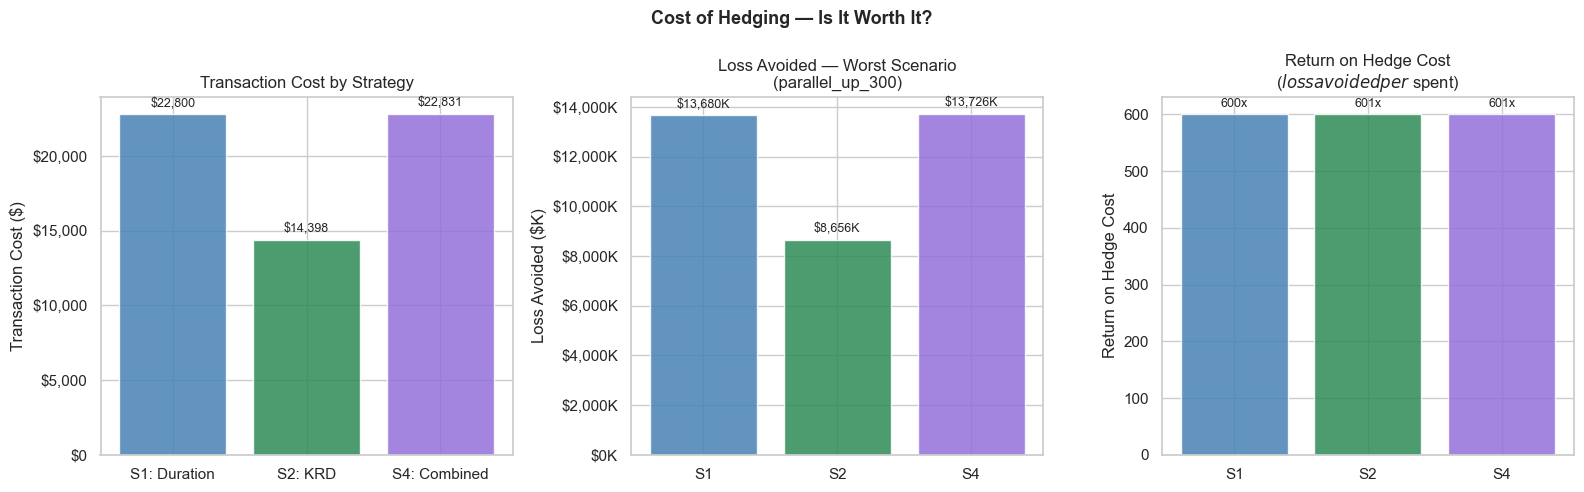


FINAL SUMMARY — WHY S4?
  Portfolio at risk           : $51.6M
  Worst case unhedged loss    : $-11,092.9K (21.5% of AUM)
  S4 cost                     : $22,831 (0.0443% of AUM)
  S4 loss avoided             : $13,726.5K
  Return on hedge cost        : 601x
  S4 avg effectiveness        : 63.0% across all scenarios

  Conclusion: S4 protects against ALL scenario types
  — parallel shifts, steepeners, flatteners,
    inversions, humps, Fed shocks, stagflation —
  at a cost of 0.0443% of AUM.


In [6]:
#── CELL 6: SECTION 5 — Cost of Hedging ──────────────────────
print("\n" + "="*65)
print("SECTION 5 — COST OF HEDGING")
print("="*65)

# Hedge specs — hardcoded from notebook 05 outputs
hedge_specs = {
    "S1: Duration": {
        "contracts": {"TY": 285},
        "cost": 285 * 80,
    },
    "S2: KRD": {
        "contracts": {"TU": 32, "FV": 59, "TY": 79, "US": 32},
        "cost": 32*20 + 59*42 + 79*80 + 32*155,
    },
    "S4: Combined": {
        "contracts": {"TU": 51, "FV": 93, "TY": 125, "US": 51},
        "cost": 51*20 + 93*42 + 125*80 + 51*155,
    },
}

for strat, spec in hedge_specs.items():
    print(f"\n  {strat}:")
    print(f"    Contracts: {spec['contracts']}")
    print(f"    Transaction cost : ${spec['cost']:,.0f}")
    print(f"    Cost as % of AUM : {spec['cost']/port_price*100:.4f}%")

# Cost vs protection chart
worst_sc  = pnl_df.loc[all_sc, "total"].idxmin()
worst_unh = pnl_df.loc[worst_sc, "total"]

protection = {
    "S1": worst_unh - hedged_df.loc[worst_sc, "s1_hedged"],
    "S2": worst_unh - hedged_df.loc[worst_sc, "s2_hedged"],
    "S4": worst_unh - hedged_df.loc[worst_sc, "s4_hedged"],
}
costs = {
    "S1": hedge_specs["S1: Duration"]["cost"],
    "S2": hedge_specs["S2: KRD"]["cost"],
    "S4": hedge_specs["S4: Combined"]["cost"],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Transaction costs
tc_labels = ["S1: Duration", "S2: KRD", "S4: Combined"]
tc_values = [v["cost"] for v in hedge_specs.values()]
bars = axes[0].bar(tc_labels, tc_values,
                   color=["steelblue","seagreen","mediumpurple"],
                   alpha=0.85, edgecolor="white")
axes[0].bar_label(bars, fmt="${:,.0f}", padding=3, fontsize=9)
axes[0].set_ylabel("Transaction Cost ($)")
axes[0].set_title("Transaction Cost by Strategy")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Chart 2: Loss avoided in worst scenario
prot_values = [abs(v)/1e3 for v in protection.values()]
bars2 = axes[1].bar(["S1","S2","S4"], prot_values,
                    color=["steelblue","seagreen","mediumpurple"],
                    alpha=0.85, edgecolor="white")
axes[1].bar_label(bars2, fmt="${:,.0f}K", padding=3, fontsize=9)
axes[1].set_ylabel("Loss Avoided ($K)")
axes[1].set_title(f"Loss Avoided — Worst Scenario\n({worst_sc})")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

# Chart 3: Return on hedge cost
roh = {s: abs(protection[s])/costs[s]
       for s in ["S1","S2","S4"]}
bars3 = axes[2].bar(roh.keys(), roh.values(),
                    color=["steelblue","seagreen","mediumpurple"],
                    alpha=0.85, edgecolor="white")
axes[2].bar_label(bars3, fmt="{:.0f}x", padding=3, fontsize=9)
axes[2].set_ylabel("Return on Hedge Cost")
axes[2].set_title("Return on Hedge Cost\n"
                  "($ loss avoided per $ spent)")

plt.suptitle("Cost of Hedging — Is It Worth It?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/pres_05_hedge_cost.png", dpi=150)
plt.show()

# Final summary
print(f"\nFINAL SUMMARY — WHY S4?")
print("="*55)
print(f"  Portfolio at risk           : ${port_price/1e6:.1f}M")
print(f"  Worst case unhedged loss    : "
      f"${worst_unh/1e3:,.1f}K ({abs(worst_unh/port_price)*100:.1f}% of AUM)")
print(f"  S4 cost                     : "
      f"${hedge_specs['S4: Combined']['cost']:,.0f} "
      f"({hedge_specs['S4: Combined']['cost']/port_price*100:.4f}% of AUM)")
print(f"  S4 loss avoided             : "
      f"${abs(protection['S4'])/1e3:,.1f}K")
print(f"  Return on hedge cost        : {roh['S4']:.0f}x")
print(f"  S4 avg effectiveness        : "
      f"{eff_df['s4_eff_%'].mean():.1f}% across all scenarios")
print(f"\n  Conclusion: S4 protects against ALL scenario types")
print(f"  — parallel shifts, steepeners, flatteners,")
print(f"    inversions, humps, Fed shocks, stagflation —")
print(f"  at a cost of {hedge_specs['S4: Combined']['cost']/port_price*100:.4f}% of AUM.")